# Layer Pricing with a Pareto Distribution

This notebook fits a Pareto (Lomax) distribution to each event's ground-up moments and pushes the moments through a layer (retention $R$, limit $L$). Pareto is chosen because it has a heavy right tail by construction, which is the property the previous lognormal and Beta notebooks lacked.

Five steps, same shape as before:

1. Two ELTs as DataFrames: an existing portfolio and a new contract.
2. Fit a Lomax distribution to each event's ground-up moments via method of moments.
3. Apply the layer to get layer mean, layer $\sigma_i$, layer $\sigma_c$ per event.
4. Add the new contract's per-event layered moments to the existing portfolio's per-event layered moments under the three rules (mean linear, $\sigma_i$ in quadrature, $\sigma_c$ linear).
5. Roll up to AAL and annual standard deviation, then read off marginal impact.

The final section lists the practical caveats of using a Pareto for this job, with citations from Klugman, Panjer & Willmot, *Loss Models: From Data to Decisions* (3rd ed., 2008).


In [1]:
import numpy as np
import pandas as pd
from scipy import stats, integrate
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
np.set_printoptions(suppress=True)


## Step 1. ELT data

Each row of the ELT is one simulated event:

- `event_id`: catalogue ID, shared across both ELTs so the same row in each refers to the same hazard realisation.
- `rate`: annual occurrence rate.
- `mean_loss`: expected ground-up loss given the event occurs.
- `sigma_i`: independent standard deviation (idiosyncratic uncertainty).
- `sigma_c`: correlated standard deviation (shared hazard uncertainty across exposed risks).

There is no `mpl` column this time. Lomax has unbounded support on $[0, \infty)$, which is exactly what makes it a heavy-tail model.

The synthetic data here is set up with $\sigma_{\text{total}} > \mu$ for every event (i.e. coefficient of variation $\text{CV} > 1$). That condition is required for a Lomax with finite variance to exist via method of moments. Real cat ELTs often do show $\text{CV} > 1$ for the rare large events because secondary uncertainty dominates.


In [2]:
existing_elt = pd.DataFrame({
    "event_id":  [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010],
    "rate":      [0.0050, 0.0080, 0.0120, 0.0200, 0.0300, 0.0150, 0.0100, 0.0040, 0.0020, 0.0010],
    "mean_loss": [ 5_000_000,  4_000_000,  3_000_000,  2_000_000,  1_500_000,
                   2_500_000,  4_000_000,  8_000_000, 12_000_000, 18_000_000],
    "sigma_i":   [ 6_000_000,  5_000_000,  4_000_000,  3_000_000,  2_500_000,
                   3_000_000,  5_000_000, 10_000_000, 15_000_000, 22_000_000],
    "sigma_c":   [ 5_000_000,  3_000_000,  2_500_000,  2_000_000,  1_500_000,
                   2_000_000,  3_500_000,  7_000_000, 10_000_000, 15_000_000],
})

new_elt = pd.DataFrame({
    "event_id":  [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010],
    "rate":      [0.0050, 0.0080, 0.0120, 0.0200, 0.0300, 0.0150, 0.0100, 0.0040, 0.0020, 0.0010],
    "mean_loss": [1_200_000, 1_000_000,   800_000,   500_000,   400_000,
                    600_000,   900_000, 2_000_000, 3_000_000, 5_000_000],
    "sigma_i":   [1_500_000, 1_300_000, 1_100_000,   800_000,   600_000,
                    900_000, 1_300_000, 2_500_000, 4_000_000, 6_500_000],
    "sigma_c":   [  900_000,   700_000,   600_000,   400_000,   350_000,
                    500_000,   700_000, 1_700_000, 2_500_000, 4_500_000],
})

existing_elt


,event_id,rate,mean_loss,sigma_i,sigma_c
0,1001,0.0050,5000000,6000000,5000000
1,1002,0.0080,4000000,5000000,3000000
2,1003,0.0120,3000000,4000000,2500000
3,1004,0.0200,2000000,3000000,2000000
4,1005,0.0300,1500000,2500000,1500000
5,1006,0.0150,2500000,3000000,2000000
6,1007,0.0100,4000000,5000000,3500000
7,1008,0.0040,8000000,10000000,7000000
8,1009,0.0020,12000000,15000000,10000000
9,1010,0.0010,18000000,22000000,15000000


In [3]:
new_elt


,event_id,rate,mean_loss,sigma_i,sigma_c
0,1001,0.0050,1200000,1500000,900000
1,1002,0.0080,1000000,1300000,700000
2,1003,0.0120,800000,1100000,600000
3,1004,0.0200,500000,800000,400000
4,1005,0.0300,400000,600000,350000
5,1006,0.0150,600000,900000,500000
6,1007,0.0100,900000,1300000,700000
7,1008,0.0040,2000000,2500000,1700000
8,1009,0.0020,3000000,4000000,2500000
9,1010,0.0010,5000000,6500000,4500000


## Step 2. Fit a Lomax distribution to each event

The Lomax (Pareto Type II) density on $[0, \infty)$ with shape $\alpha$ and scale $\theta$ is:

$$f(x) = \frac{\alpha \theta^{\alpha}}{(x + \theta)^{\alpha + 1}}, \qquad S(x) = \left(\frac{\theta}{x + \theta}\right)^{\alpha}$$

The first two moments (when they exist) are:

$$\mu = \frac{\theta}{\alpha - 1} \quad (\alpha > 1), \qquad \sigma^2 = \frac{\alpha \theta^2}{(\alpha - 1)^2 (\alpha - 2)} \quad (\alpha > 2)$$

For method of moments we need to solve for $(\alpha, \theta)$ from $(\mu, \sigma_{\text{total}})$. Define the squared coefficient of variation $\text{CV}^2 = \sigma_{\text{total}}^2 / \mu^2$. Then:

$$\text{CV}^2 = \frac{\sigma^2}{\mu^2} = \frac{\alpha}{\alpha - 2}$$

Solving for $\alpha$:

$$\alpha = \frac{2 \, \text{CV}^2}{\text{CV}^2 - 1}$$

And then $\theta$ falls out of the mean equation:

$$\theta = \mu \, (\alpha - 1)$$

The condition $\text{CV} > 1$ is the price of admission. If the event's $\sigma_{\text{total}}$ is smaller than its mean, no finite-variance Lomax matches both moments, and the analyst either has to drop down to an infinite-variance Lomax (where MoM does not work), use a different parameterisation, or pick a different family. Heavy-tailed models genuinely require heavy-tailed data.


In [4]:
def fit_lomax(df: pd.DataFrame) -> pd.DataFrame:
    """Fit a Lomax distribution to each row's (mean_loss, sigma_total) via method of moments.

    Adds columns: sigma_total, cv, alpha, theta.
    Raises ValueError if any row has CV <= 1 (no finite-variance Lomax fit exists).
    """
    out = df.copy()
    out["sigma_total"] = np.sqrt(out["sigma_i"] ** 2 + out["sigma_c"] ** 2)
    out["cv"] = out["sigma_total"] / out["mean_loss"]

    feasible = out["cv"] > 1.0
    if not feasible.all():
        bad = out.loc[~feasible, ["event_id", "mean_loss", "sigma_total", "cv"]]
        raise ValueError(f"Lomax MoM infeasible (CV <= 1) for these events:\n{bad}")

    cv2 = out["cv"] ** 2
    out["alpha"] = 2 * cv2 / (cv2 - 1)
    out["theta"] = out["mean_loss"] * (out["alpha"] - 1)
    return out


existing_fit = fit_lomax(existing_elt)
new_fit = fit_lomax(new_elt)
existing_fit[["event_id", "mean_loss", "sigma_total", "cv", "alpha", "theta"]]


,event_id,mean_loss,sigma_total,cv,alpha,theta
0,1001,5000000,"7,810,249.6759",1.5620,3.3889,"11,944,444.4444"
1,1002,4000000,"5,830,951.8948",1.4577,3.7778,"11,111,111.1111"
2,1003,3000000,"4,716,990.5660",1.5723,3.3585,"7,075,471.6981"
3,1004,2000000,"3,605,551.2755",1.8028,2.8889,"3,777,777.7778"
4,1005,1500000,"2,915,475.9474",1.9437,2.7200,"2,580,000.0000"
5,1006,2500000,"3,605,551.2755",1.4422,3.8519,"7,129,629.6296"
6,1007,4000000,"6,103,277.8079",1.5258,3.5059,"10,023,529.4118"
7,1008,8000000,"12,206,555.6157",1.5258,3.5059,"20,047,058.8235"
8,1009,12000000,"18,027,756.3773",1.5023,3.5912,"31,093,922.6519"
9,1010,18000000,"26,627,053.9114",1.4793,3.6831,"48,296,103.8961"


The shape parameter $\alpha$ controls the weight in the tail. Smaller $\alpha$ means a heavier tail; large $\alpha$ pushes the distribution closer to a thin-tailed body. Notice the $\alpha$ values cluster around 4 to 6 here, which is "moderately heavy". A real cat severity calibration on excess data often gives $\alpha$ in the 1.5 to 3 range.


In [5]:
new_fit[["event_id", "mean_loss", "sigma_total", "cv", "alpha", "theta"]]


,event_id,mean_loss,sigma_total,cv,alpha,theta
0,1001,1200000,"1,749,285.5685",1.4577,3.7778,"3,333,333.3333"
1,1002,1000000,"1,476,482.3060",1.4765,3.6949,"2,694,915.2542"
2,1003,800000,"1,252,996.4086",1.5662,3.3763,"1,901,075.2688"
3,1004,500000,"894,427.1910",1.7889,2.9091,"954,545.4545"
4,1005,400000,"694,622.1995",1.7366,2.9922,"796,899.2248"
5,1006,600000,"1,029,563.0141",1.7159,3.0286,"1,217,142.8571"
6,1007,900000,"1,476,482.3060",1.6405,3.1825,"1,964,233.5766"
7,1008,2000000,"3,023,243.2916",1.5116,3.5564,"5,112,840.4669"
8,1009,3000000,"4,716,990.5660",1.5723,3.3585,"7,075,471.6981"
9,1010,5000000,"7,905,694.1504",1.5811,3.3333,"11,666,666.6667"


## Step 3. Apply the layer

The layered loss for a single event is:

$$Y = \min\bigl(\max(X - R, 0), \, L\bigr)$$

### Layer mean (closed form)

$$\mathbb{E}[Y] = \int_R^{R + L} S(x) \, dx = \int_R^{R + L} \left(\frac{\theta}{x + \theta}\right)^{\alpha} dx$$

For $\alpha \neq 1$ this integrates in closed form:

$$\mathbb{E}[Y] = \frac{\theta}{\alpha - 1} \left[ \left(\frac{\theta}{R + \theta}\right)^{\alpha - 1} - \left(\frac{\theta}{R + L + \theta}\right)^{\alpha - 1} \right]$$

Plain English: the survival function of a Lomax is itself a power of $\theta / (x + \theta)$, and the antiderivative of that is the same expression with the exponent dropped by one and divided by $(\alpha - 1)$. Plug in the bounds $R$ and $R + L$ and subtract.

### Layer second moment (numerical)

$$\mathbb{E}[Y^2] = \int_0^{L} 2y \, S(R + y) \, dy$$

This is the layer-cake (tail-integral) formula for $\mathbb{E}[Y^2]$. The cap atom at $y = L$ is implicitly captured by the upper boundary of integration; integration by parts confirms there is no extra additive term. Computed numerically with `scipy.integrate.quad`.

### Layer variance and the $\sigma_i$ / $\sigma_c$ split

$$\mathrm{Var}[Y] = \mathbb{E}[Y^2] - \mathbb{E}[Y]^2$$

$$f_i = \frac{\sigma_i^2}{\sigma_i^2 + \sigma_c^2}, \qquad f_c = \frac{\sigma_c^2}{\sigma_i^2 + \sigma_c^2}$$

$$\sigma_i^{(\text{layer})} = \sqrt{f_i \cdot \mathrm{Var}[Y]}, \qquad \sigma_c^{(\text{layer})} = \sqrt{f_c \cdot \mathrm{Var}[Y]}$$

Same proportional-split trick as before. The split is an approximation; see the caveats section.


In [6]:
def lomax_survival(x: float, alpha: float, theta: float) -> float:
    if x <= 0.0:
        return 1.0
    return (theta / (x + theta)) ** alpha


def lomax_layer_mean(alpha: float, theta: float, R: float, L: float) -> float:
    """Closed-form layer mean for Lomax(alpha, theta), assuming alpha != 1."""
    s_R = (theta / (R + theta)) ** (alpha - 1)
    s_RL = (theta / (R + L + theta)) ** (alpha - 1)
    return (theta / (alpha - 1)) * (s_R - s_RL)


def lomax_layer_e2(alpha: float, theta: float, R: float, L: float) -> float:
    """Numerical second moment of the layered loss."""
    integrand = lambda y: 2.0 * y * lomax_survival(R + y, alpha, theta)
    val, _ = integrate.quad(integrand, 0.0, L, limit=200, epsabs=1.0, epsrel=1e-6)
    return val


def apply_layer_lomax(fit_df: pd.DataFrame, retention: float, limit: float) -> pd.DataFrame:
    out = fit_df.copy()
    means, sdis, sdcs = [], [], []
    for _, row in out.iterrows():
        alpha, theta = row["alpha"], row["theta"]
        m_layer = lomax_layer_mean(alpha, theta, retention, limit)
        e2 = lomax_layer_e2(alpha, theta, retention, limit)
        v_layer = max(e2 - m_layer ** 2, 0.0)

        sig_total_sq = row["sigma_i"] ** 2 + row["sigma_c"] ** 2
        if sig_total_sq > 0:
            f_i = (row["sigma_i"] ** 2) / sig_total_sq
            f_c = (row["sigma_c"] ** 2) / sig_total_sq
        else:
            f_i = f_c = 0.0
        means.append(m_layer)
        sdis.append(np.sqrt(f_i * v_layer))
        sdcs.append(np.sqrt(f_c * v_layer))
    out["layer_mean"] = means
    out["layer_sigma_i"] = sdis
    out["layer_sigma_c"] = sdcs
    return out


RETENTION = 5_000_000
LIMIT = 20_000_000

existing_layer = apply_layer_lomax(existing_fit, RETENTION, LIMIT)
new_layer = apply_layer_lomax(new_fit, RETENTION, LIMIT)

existing_layer[["event_id", "mean_loss", "alpha", "theta", "layer_mean", "layer_sigma_i", "layer_sigma_c"]]


,event_id,mean_loss,alpha,theta,layer_mean,layer_sigma_i,layer_sigma_c
0,1001,5000000,3.3889,"11,944,444.4444","1,831,754.3875","3,273,818.6727","2,728,182.2273"
1,1002,4000000,3.7778,"11,111,111.1111","1,273,589.7066","2,970,257.0513","1,782,154.2308"
2,1003,3000000,3.3585,"7,075,471.6981","765,444.4038","2,263,594.0104","1,414,746.2565"
3,1004,2000000,2.8889,"3,777,777.7778","363,645.0389","1,529,417.7576","1,019,611.8384"
4,1005,1500000,2.7200,"2,580,000.0000","209,504.9730","1,191,971.9160","715,183.1496"
5,1006,2500000,3.8519,"7,129,629.6296","515,130.7120","1,741,293.9029","1,160,862.6019"
6,1007,4000000,3.5059,"10,023,529.4118","1,276,948.2316","2,869,362.3973","2,008,553.6781"
7,1008,8000000,3.5059,"20,047,058.8235","3,526,926.2780","4,837,483.1580","3,386,238.2106"
8,1009,12000000,3.5912,"31,093,922.6519","5,552,714.5603","5,978,342.5731","3,985,561.7154"
9,1010,18000000,3.6831,"48,296,103.8961","7,941,831.7637","6,667,351.2288","4,545,921.2924"


In [7]:
new_layer[["event_id", "mean_loss", "alpha", "theta", "layer_mean", "layer_sigma_i", "layer_sigma_c"]]


,event_id,mean_loss,alpha,theta,layer_mean,layer_sigma_i,layer_sigma_c
0,1001,1200000,3.7778,"3,333,333.3333","91,000.0806","690,457.0256","414,274.2153"
1,1002,1000000,3.6949,"2,694,915.2542","57,285.8014","555,176.1045","298,940.9793"
2,1003,800000,3.3763,"1,901,075.2688","35,897.0063","444,964.7803","242,708.0620"
3,1004,500000,2.9091,"954,545.4545","14,262.3745","296,553.3151","148,276.6575"
4,1005,400000,2.9922,"796,899.2248","7,284.2317","199,914.1277","116,616.5745"
5,1006,600000,3.0286,"1,217,142.8571","20,764.5150","346,520.5504","192,511.4169"
6,1007,900000,3.1825,"1,964,233.5766","53,868.5561","565,837.0122","304,681.4681"
7,1008,2000000,3.5564,"5,112,840.4669","328,280.3330","1,370,291.7493","931,798.3896"
8,1009,3000000,3.3585,"7,075,471.6981","765,444.4038","2,263,594.0104","1,414,746.2565"
9,1010,5000000,3.3333,"11,666,666.6667","1,829,786.9988","3,508,180.3104","2,428,740.2149"


The chart below shows ground-up mean vs. layer mean for the existing portfolio. Compared with the Beta and lognormal versions, you should see notably larger layer means for events whose ground-up mean sits below the retention. The reason is the heavy Pareto tail: even when $\mu \ll R$, the survival function $S(R)$ does not vanish quickly, so there is a meaningful contribution from the right tail crossing into the layer.


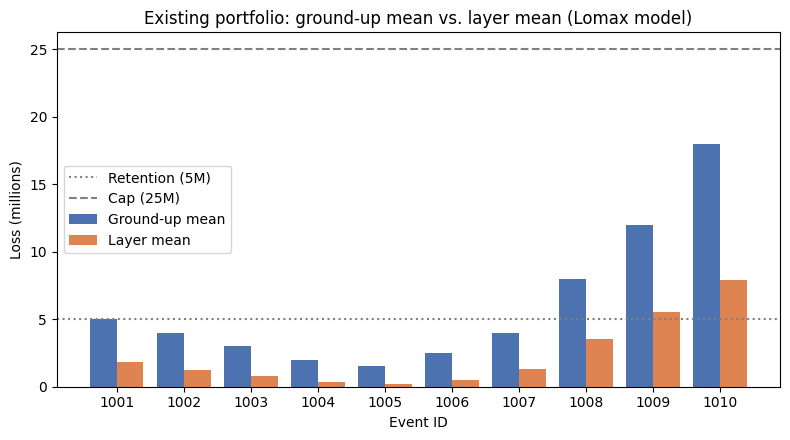

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(existing_layer))
width = 0.4
ax.bar(x - width / 2, existing_layer["mean_loss"] / 1e6, width, label="Ground-up mean", color="#4c72b0")
ax.bar(x + width / 2, existing_layer["layer_mean"] / 1e6, width, label="Layer mean", color="#dd8452")
ax.axhline(RETENTION / 1e6, color="grey", linestyle=":", label=f"Retention ({RETENTION/1e6:.0f}M)")
ax.axhline((RETENTION + LIMIT) / 1e6, color="grey", linestyle="--", label=f"Cap ({(RETENTION+LIMIT)/1e6:.0f}M)")
ax.set_xticks(x)
ax.set_xticklabels(existing_layer["event_id"], rotation=0)
ax.set_xlabel("Event ID")
ax.set_ylabel("Loss (millions)")
ax.set_title("Existing portfolio: ground-up mean vs. layer mean (Lomax model)")
ax.legend()
plt.tight_layout()
plt.show()


## Step 4. Add the new contract to the existing portfolio

For every Event ID, the existing portfolio's row and the new contract's row refer to the same hazard realisation, so they aggregate under the three rules:

### Mean adds linearly

$$\mu_{\text{port + new}}(k) = \mu_{\text{port}}(k) + \mu_{\text{new}}(k)$$

### Independent $\sigma$ adds in quadrature

$$\sigma_i^{(\text{port + new})}(k) = \sqrt{\bigl(\sigma_i^{(\text{port})}(k)\bigr)^2 + \bigl(\sigma_i^{(\text{new})}(k)\bigr)^2}$$

### Correlated $\sigma$ adds linearly

$$\sigma_c^{(\text{port + new})}(k) = \sigma_c^{(\text{port})}(k) + \sigma_c^{(\text{new})}(k)$$

The reasoning is the same regardless of the severity distribution: independent components have correlation 0 (variances sum), correlated components have correlation 1 (standard deviations sum).


In [9]:
def add_to_portfolio(port_layer: pd.DataFrame, new_layer: pd.DataFrame) -> pd.DataFrame:
    merged = port_layer.merge(
        new_layer[["event_id", "rate", "layer_mean", "layer_sigma_i", "layer_sigma_c"]],
        on=["event_id", "rate"],
        suffixes=("_port", "_new"),
    )
    merged["layer_mean_total"] = merged["layer_mean_port"] + merged["layer_mean_new"]
    merged["layer_sigma_i_total"] = np.sqrt(
        merged["layer_sigma_i_port"] ** 2 + merged["layer_sigma_i_new"] ** 2
    )
    merged["layer_sigma_c_total"] = (
        merged["layer_sigma_c_port"] + merged["layer_sigma_c_new"]
    )
    return merged


combined = add_to_portfolio(existing_layer, new_layer)
cols = ["event_id", "rate",
        "layer_mean_port", "layer_mean_new", "layer_mean_total",
        "layer_sigma_i_port", "layer_sigma_i_new", "layer_sigma_i_total",
        "layer_sigma_c_port", "layer_sigma_c_new", "layer_sigma_c_total"]
combined[cols]


,event_id,rate,layer_mean_port,layer_mean_new,layer_mean_total,layer_sigma_i_port,layer_sigma_i_new,layer_sigma_i_total,layer_sigma_c_port,layer_sigma_c_new,layer_sigma_c_total
0,1001,0.0050,"1,831,754.3875","91,000.0806","1,922,754.4682","3,273,818.6727","690,457.0256","3,345,836.1595","2,728,182.2273","414,274.2153","3,142,456.4426"
1,1002,0.0080,"1,273,589.7066","57,285.8014","1,330,875.5080","2,970,257.0513","555,176.1045","3,021,696.1227","1,782,154.2308","298,940.9793","2,081,095.2101"
2,1003,0.0120,"765,444.4038","35,897.0063","801,341.4101","2,263,594.0104","444,964.7803","2,306,913.8474","1,414,746.2565","242,708.0620","1,657,454.3185"
3,1004,0.0200,"363,645.0389","14,262.3745","377,907.4134","1,529,417.7576","296,553.3151","1,557,903.2530","1,019,611.8384","148,276.6575","1,167,888.4959"
4,1005,0.0300,"209,504.9730","7,284.2317","216,789.2047","1,191,971.9160","199,914.1277","1,208,620.1665","715,183.1496","116,616.5745","831,799.7241"
5,1006,0.0150,"515,130.7120","20,764.5150","535,895.2270","1,741,293.9029","346,520.5504","1,775,438.2411","1,160,862.6019","192,511.4169","1,353,374.0188"
6,1007,0.0100,"1,276,948.2316","53,868.5561","1,330,816.7876","2,869,362.3973","565,837.0122","2,924,621.7006","2,008,553.6781","304,681.4681","2,313,235.1462"
7,1008,0.0040,"3,526,926.2780","328,280.3330","3,855,206.6111","4,837,483.1580","1,370,291.7493","5,027,816.9002","3,386,238.2106","931,798.3896","4,318,036.6001"
8,1009,0.0020,"5,552,714.5603","765,444.4038","6,318,158.9641","5,978,342.5731","2,263,594.0104","6,392,529.8407","3,985,561.7154","1,414,746.2565","5,400,307.9719"
9,1010,0.0010,"7,941,831.7637","1,829,786.9988","9,771,618.7625","6,667,351.2288","3,508,180.3104","7,533,983.1098","4,545,921.2924","2,428,740.2149","6,974,661.5073"


## Step 5. Portfolio metrics and marginal impact

Compound-Poisson roll-up across events:

$$\text{AAL} = \sum_k \lambda_k \mu_k$$

$$\mathrm{Var}_{\text{annual}} = \sum_k \lambda_k \bigl(\mu_k^2 + \sigma_{i,k}^2 + \sigma_{c,k}^2\bigr)$$

$$\sigma_{\text{annual}} = \sqrt{\mathrm{Var}_{\text{annual}}}$$

The marginal impact of the new contract is the difference between the metrics computed on the totals and on the existing portfolio alone.


In [10]:
def portfolio_metrics(layer_df: pd.DataFrame, mean_col: str, sigma_i_col: str, sigma_c_col: str):
    rate = layer_df["rate"]
    mu = layer_df[mean_col]
    s_i = layer_df[sigma_i_col]
    s_c = layer_df[sigma_c_col]
    aal = float((rate * mu).sum())
    annual_var = float((rate * (mu ** 2 + s_i ** 2 + s_c ** 2)).sum())
    return aal, np.sqrt(annual_var)


port_aal, port_sd = portfolio_metrics(
    combined, "layer_mean_port", "layer_sigma_i_port", "layer_sigma_c_port"
)
total_aal, total_sd = portfolio_metrics(
    combined, "layer_mean_total", "layer_sigma_i_total", "layer_sigma_c_total"
)
new_aal, new_sd = portfolio_metrics(
    new_layer, "layer_mean", "layer_sigma_i", "layer_sigma_c"
)

summary = pd.DataFrame({
    "metric": ["AAL", "Annual std dev"],
    "existing portfolio": [port_aal, port_sd],
    "new contract standalone": [new_aal, new_sd],
    "portfolio + new": [total_aal, total_sd],
    "marginal impact": [total_aal - port_aal, total_sd - port_sd],
})
summary


,metric,existing portfolio,new contract standalone,portfolio + new,marginal impact
0,AAL,"95,742.2814","7,371.7758","103,114.0572","7,371.7758"
1,Annual std dev,"1,062,816.0828","261,369.0844","1,177,560.7799","114,744.6971"


In [11]:
marginal_sd_diversification = (port_sd + new_sd) - total_sd
print(f"Naive sum of standalone SDs: {(port_sd + new_sd):,.0f}")
print(f"Actual portfolio + new SD:    {total_sd:,.0f}")
print(f"Diversification benefit:      {marginal_sd_diversification:,.0f}")


Naive sum of standalone SDs: 1,324,185
Actual portfolio + new SD:    1,177,561
Diversification benefit:      146,624


## Caveats of using a Pareto for layer mean / $\sigma_i$ / $\sigma_c$

This section is grounded in *Loss Models: From Data to Decisions* (Klugman, Panjer & Willmot, 3rd ed., 2008), referred to as KPW. Page numbers are from that edition.

### 1. Pareto sits in the right family for excess work, by KPW's own classification

KPW Section 5.6.1 (p. 84) introduces the family used for excess and reinsurance: *"There are times when actuaries are only interested in the distribution of large losses. One example would be per-claim reinsurance arrangements..."* The chapter then discusses the Generalised Pareto Distribution (GPD). The Lomax form used here is GPD with positive shape and is a member of the recommended family.

### 2. Method of moments is fragile precisely when the tail matters

KPW Section 15.2.1 (p. 381): *"Estimation by the method of moments and percentile matching is often easy to do, but these estimators tend to perform poorly mainly because they use a few features of the data, rather than the entire set of observations. It is particularly important to use as much information as possible when the population has a heavy right tail."*

For Pareto MoM specifically, the second moment depends on $1/(\alpha - 2)$, so small errors in the input $\sigma$ translate into large swings in $\alpha$ and very large swings in $\theta$. The fit is sensitive in exactly the regime where the tail matters most.

### 3. The CV > 1 constraint is a real restriction

To get $\alpha > 2$ (finite variance) the input must satisfy $\sigma_{\text{total}} > \mu$. ELT events that come out of a cat model with low secondary uncertainty relative to mean will violate this. Three ways out, none of them ideal:

1. Use an infinite-variance Lomax with $1 < \alpha \le 2$. Layer mean is finite (so pricing of bounded layers still works), but the layer variance and any moment-based aggregation does not. The $\sigma_i$ / $\sigma_c$ split breaks immediately.
2. Force-fit by relaxing $\sigma_{\text{total}}$. Defeats the purpose.
3. Switch families per event. Mixed model, defensible but harder to communicate.

### 4. Lomax has a finite mean but no upper bound

This is a feature for the tail (no artificial cap, unlike Beta), but it is also a modelling assumption. For lines where there is a real engineering cap on loss (a single building cannot lose more than its full reinstatement cost), Lomax assigns positive probability above that cap. For layered pricing this rarely bites because the layer is itself capped at $R + L$, but it is worth being aware of.

### 5. The $\sigma_i$ / $\sigma_c$ proportional split is still an approximation

Same caveat as in the Beta notebook. The Pareto layer transformation gives a single layer variance via the limited expected value approach. Splitting that variance into $\sigma_i^{(\text{layer})}$ and $\sigma_c^{(\text{layer})}$ in the same proportion as the ground-up split is an assumption, not a derived result. KPW does not address the $\sigma_i$ / $\sigma_c$ decomposition because it is a cat-modelling convention rather than a textbook actuarial one. The split is reasonable for layers in the body of the loss distribution and increasingly off as the layer attaches into the tail (where the heavy-tail correlated component should arguably grow faster than the independent one, not stay in the same proportion).

### 6. Single-distribution fit vs. peaks-over-threshold

The cleanest theoretical use of Pareto is the peaks-over-threshold (POT) approach: pick a threshold $u$, fit a GPD only to the excesses $X - u | X > u$. KPW Section 5.6.1 frames the asymptotic theory (pp. 84 to 85) around this approach. Fitting Lomax to the entire ground-up moment pair $(\mu, \sigma)$ as we do here is a simplification. It works because the Lomax happens to be exactly GPD with location 0, but the parameters that minimise tail error from the body are not the parameters from a moment match.

### 7. Sensitivity to extreme events in the rate column

The annual standard deviation formula $\sum_k \lambda_k (\mu_k^2 + \sigma_k^2)$ is dominated by the events with the largest $\mu_k^2 + \sigma_k^2$, even if their rate $\lambda_k$ is small. With heavy-tailed Pareto fits, those values can be large. A small change in $\alpha$ for the rarest event can move the portfolio standard deviation noticeably. Always do a one-leave-out sensitivity on the top few events when pricing on a Lomax-fit ELT.


## Summary

The notebook does five things. Two ELTs as DataFrames; method-of-moments fit of a Lomax to each event using $\alpha = 2 \text{CV}^2 / (\text{CV}^2 - 1)$ and $\theta = \mu (\alpha - 1)$; closed-form layer mean from the Lomax survival integral, with the layer second moment computed numerically via the tail-integral formula; proportional split into layer $\sigma_i$ and $\sigma_c$; Event-ID-wise aggregation and compound-Poisson roll-up to AAL and annual standard deviation.

Pareto's structural advantage is the heavy tail. Layers attaching well above the mean still see meaningful contribution from rare-large draws, and the model does not bottom out at zero the way a thin-tailed fit on the same moments would. The price paid is the $\text{CV} > 1$ constraint and high parameter sensitivity in the tail, both of which are flagged in the caveats above.
